# Field validation — `native_fields` (SURF pipeline)

End-to-end validation of every calculated field in the **native_fields** surface subset: the notebook RUNs the pipeline, LOADs its own output, and validates each field with dependency-chain maps, PDFs, and a literature comparison.

| | |
|---|---|
| Subset | `native_fields` (SURF) |
| Timestep | 2012-11-09 12:00:00 (`20121109_120000`) |
| run_id | `field_validation_v1` |
| Plan | `prompts/field_validation.md` |
| Field reference | `docs/Fields.md` |

Raw model channels are validated directly; U/V are the only computed channels (staggered→tracer interpolation + CS/SN rotation).  The rotation machinery itself is exercised further in `kinematic.ipynb` (Jacobian) and referenced from there.

## Section 1 — RUN the SURF pipeline for this subset + timestep

One cell (pattern from
`notebooks/notebooks_global/running_generate_global_script.ipynb`).
Existing stores for this date are skipped unless `--clobber` is added,
so re-running is a cheap no-op.

In [1]:
# Section 1: run the SURF pipeline for this subset and timestep.
SUBSET   = "native_fields"
PIPELINE = "SURF"
RUN_ID   = "field_validation_v1"
DATE     = "2012-11-09 12:00:00"   # single validation timestep

!generate-global \
    --config ../../../configs/global/run/field_validation_surface.yaml \
    --pipeline $PIPELINE \
    --subset $SUBSET \
    --run_id $RUN_ID

2026-08-03 23:44:26,289 | INFO | Log file: /home/lhoffma2/git/llc4320-native-grid-preprocessing/notebooks/notebooks_field_validation/test_logs/field_validation_v1/native_fields_20260804_064426.log
2026-08-03 23:44:26,289 | INFO | Unified global pipeline starting.
2026-08-03 23:44:26,290 | INFO | Pipeline: SURF
2026-08-03 23:44:26,290 | INFO | Active subsets: ['native_fields']
2026-08-03 23:44:26,290 | INFO | Depth suffixes (YAML override): None
2026-08-03 23:44:26,290 | INFO | Dates: ['2012-11-09 12:00:00']
2026-08-03 23:44:26,290 | INFO | Pre-flight plan (zarr existence per subset/date):
2026-08-03 23:44:26,298 | INFO | Found credentials in shared credentials file: ~/.aws/credentials
2026-08-03 23:44:26,661 | INFO |   native_fields          2012-11-09 12:00:00  ->  GENERATE (zarr store missing)
2026-08-03 23:44:27,127 | INFO | State start
2026-08-03 23:44:27,131 | INFO |   Scheduler at:     tcp://127.0.0.1:44377
2026-08-03 23:44:27,131 | INFO |   dashboard at:  http://127.0.0.1:8787/s

## Section 2 — LOAD the data generated in Section 1

One cell (pattern from
`notebooks/notebooks_global/assess_generate_global_script.ipynb`):
product reader + grid reader, with shape/date confirmation printout.

In [2]:
# Section 2: load the store written in Section 1 + the shared grid.
import numpy as np
import matplotlib.pyplot as plt

import dbof.io.filesystems as filesystems
import dbof.global_dataset_creation.zarr_dataset_global as zarr_dataset
import dbof.global_dataset_creation.zarr_grid_global as zarr_grid
from dbof.global_dataset_creation.subset_definitions import (
    get_subset_definition,
)

S3_ENDPOINT = "https://s3-west.nrp-nautilus.io"
BUCKET      = "dbof"
FOLDER      = "surface_fields"       # SURF output folder
DATE_PREFIX = "20121109_120000"      # matches DATE in Section 1

defn = get_subset_definition(PIPELINE, SUBSET)
# get_subset_definition already folds per-pipeline extras (e.g.
# oceQnet for SURF) into model_data_feature_channels.
CHANNELS = (list(defn["model_data_feature_channels"])
            + list(defn["compute_features_channels"]))

fs, _ = filesystems.create_s3_filesystems(S3_ENDPOINT)
reader = zarr_dataset.GlobalZarrDatasetReader(
    bucket=BUCKET, folder=FOLDER, run_id=RUN_ID,
    dataset_name=defn["dataset_name"], date_prefix=DATE_PREFIX, fs=fs,
)

fs_grid, _ = filesystems.create_s3_filesystems(S3_ENDPOINT)
grid_reader = zarr_grid.GlobalGridZarrReader(
    bucket=BUCKET, folder="LLC4320_GRID_2D",
    dataset_name="llc4320_grid.zarr", fs=fs_grid,
)
XC, YC = grid_reader.lon, grid_reader.lat

print(reader)
print(f"channels  : {reader.channel_names}")
print(f"shape     : {reader.shape}  (C, H, W)")
print(f"iteration : {reader.iteration}")
print(f"grid      : XC {XC.shape}, "
      f"lon [{XC.min():.1f}, {XC.max():.1f}], "
      f"lat [{YC.min():.1f}, {YC.max():.1f}]")

channels  : ['Theta', 'Salt', 'Eta', 'W', 'U', 'V']
shape     : (6, 12960, 17280)  (C, H, W)
iteration : 1473984
grid      : XC (12960, 17280), lon [-180.0, 180.0], lat [-90.0, 72.0]


## Section 3 — SUBSET: `native_fields`

Channels (verbatim from `subset_definitions.SURFACE_SUBSETS`):

raw — `Theta`, `Salt`, `Eta`, `W`; computed — `U`, `V`

In [3]:
# Section 3: guard — store channels must match the code definition.
print(f"subset '{SUBSET}': {len(CHANNELS)} channels")
for ch in CHANNELS:
    print(f"  - {ch}")
assert set(reader.channel_names) == set(CHANNELS), (
    "store channels differ from subset_definitions — regenerate the "
    "store (Section 1, --clobber) or check the code definition")
print("OK: store channel set matches subset_definitions")

subset 'native_fields': 6 channels
  - Theta
  - Salt
  - Eta
  - W
  - U
  - V
OK: store channel set matches subset_definitions


## Section 4 — Field & dependency table

| FIELD NAME | UNITS | EQUATION | DEPENDENCIES | LOCATION OF CALC IN CODE |
|---|---|---|---|---|
| Theta | °C | model output | — | OSN llc_surf kerchunk |
| Salt | psu | model output | — | OSN llc_surf kerchunk |
| Eta | m | model output | — | OSN llc_surf kerchunk |
| W | m s⁻¹ | model output (top interface, k_l=0 — ≈0 by construction; noted) | — | OSN llc_surf kerchunk |
| U | m s⁻¹ | staggered U,V → interp to tracer pts → CS/SN rotation → eastward | raw U, V; CS, SN | `calculate_fields.geographic_velocity` → `native_gradient.rotate_vector_to_geographic` |
| V | m s⁻¹ | same → northward | raw U, V; CS, SN | `calculate_fields.geographic_velocity` |

Processing operations: land masking (`hFacC == 0`, NaN);
staggered→tracer interpolation (U at i_g, V at j_g) for U/V only;
CS/SN rotation; **no** differentiation; face→lat-lon stitching;
global row downsampled `[::12, ::12]`.  Raw staggered U/V cannot be
stitched (staggered dims) — the rotation step is validated via the
table and the Jacobian chains in `kinematic.ipynb`.

In [4]:
# Slice the STORE channels to the validation domains (live fields, if
# any, were sliced in the previous cell).  Full-res arrays released
# immediately after slicing.
from dbof.plotting import regions
from dbof.plotting.field_cmaps import load_field_cmaps

CMAP_CFG, DIVERGING = load_field_cmaps()

# region_arrays[field][region] = (x, y, arr)
region_arrays = globals().get("region_arrays", {})
SLICE_REGIONS = (regions.REGION_ORDER
                 + globals().get("EXTRA_REGIONS", []))
for ch in CHANNELS:
    arr = reader.get_channel_snapshot(ch)
    region_arrays[ch] = regions.select_all_regions(
        arr, XC, YC, names=SLICE_REGIONS)
    del arr

for ch in region_arrays:
    x, y, sub = region_arrays[ch]["gulf_stream"]
    print(f"{ch:24s} gulf_stream {sub.shape}  "
          f"min {np.nanmin(sub):.3g}  max {np.nanmax(sub):.3g}")

Theta                    gulf_stream (1282, 1920)  min 6.14  max 27.3
Salt                     gulf_stream (1282, 1920)  min 26.1  max 38.8
Eta                      gulf_stream (1282, 1920)  min -1.55  max 2.68
W                        gulf_stream (1282, 1920)  min -0.000907  max 5.18e-05
U                        gulf_stream (1282, 1920)  min -4.14  max 4.13
V                        gulf_stream (1282, 1920)  min -4.82  max 2.18


## Section 5 — Per-field validation

- **Figure 1 — maps**: columns = the field's full dependency chain
  (raw → components → final; every computed step is shown), rows =
  validation domains.  One shared colour scale per column; land/halo
  NaNs gray; regional boxes on the global row.
- **Figure 2 — PDFs**: same grid.  Probability density; land +
  halo-rim NaNs removed; bins shared per field across domains;
  Eq. Pacific row |lat|>2° filtered for f-normalised fields.
- **Literature comparisons** live in Section 6 at the end of the
  notebook — one subsection PER REFERENCE (a reference may validate
  several fields at once), only where a reference exists.  Images in
  `../literature_figures/`, named
  `{field(s)}_{Citation}_{description}.png`.

In [5]:
# Section 5 helpers: one call per figure, shared by all fields.
from pathlib import Path

import cartopy.crs as ccrs

from dbof.plotting.global_maps import plot_global_field
from dbof.plotting.pipeline_grids import (
    pipeline_map_grid, mask_wrap_cells, LAND_COLOR,
)
from dbof.plotting.pdfs import pipeline_pdf_grid
from dbof.plotting.literature_comparison import side_by_side

# Flat literature directory; files named
# {field}_{Citation}_{description}.png
LIT_DIR = Path("../literature_figures")

# Full dependency chain per field (columns of Figures 1-2), including
# component-level intermediates (gradient / Jacobian components).
CHAINS = {
    "Theta": ["Theta"],
    "Salt": ["Salt"],
    "Eta": ["Eta"],
    "W": ["W"],
    "U": ["U"],
    "V": ["V"],
}

# f-normalised fields: |lat|>2 deg filter on the Eq. Pacific row of
# the PDFs only (maps annotated instead) — plan Clarification 8.
F_NORM = set()

# Fields drawn/binned on log scales (∝-squared fields).
LOG_FIELDS = set()

PDF_NOTE = ("PDFs: density; land+rim NaNs removed; shared bins "
            "across domains; log10-x for \u221d-squared fields")


def _pdf_arrays(field):
    """Region arrays for the PDF grid of one field.

    Applies the |lat|>2 deg filter to the Eq. Pacific row for
    f-normalised chain members (filter stated in the figure title).
    Inputs: field (str).  Outputs: dict like region_arrays.
    Generated by LH and Claude
    """
    out = {}
    for f in CHAINS[field]:
        d = dict(region_arrays[f])
        if f in F_NORM:
            x, y, a = d["eq_pacific"]
            d["eq_pacific"] = (x, y,
                               np.where(np.abs(y) > 2.0, a, np.nan))
        out[f] = d
    return out


def figure1_maps(field):
    """Figure 1: dependency-chain map grid for one field.

    Inputs: field (str) — output channel name (key into CHAINS).
    Outputs: displays the figure.
    Generated by LH and Claude
    """
    note = (" | f-normalised: Eq. Pacific extreme near equator "
            "(expected)" if field in F_NORM else "")
    pipeline_map_grid(
        CHAINS[field], region_arrays, CMAP_CFG,
        diverging_cmaps=DIVERGING, log_scale_channels=LOG_FIELDS,
        suptitle=f"Figure 1 \u2014 {field}: pipeline maps{note}",
    )
    plt.show()


def figure2_pdfs(field):
    """Figure 2: dependency-chain PDF grid for one field.

    Inputs: field (str) — output channel name (key into CHAINS).
    Outputs: displays the figure.
    Generated by LH and Claude
    """
    note = (" | Eq. Pacific: |lat|>2\u00b0 filter (f-normalised)"
            if set(CHAINS[field]) & F_NORM else "")
    pipeline_pdf_grid(
        CHAINS[field], _pdf_arrays(field), CMAP_CFG,
        log10_fields=LOG_FIELDS,
        suptitle=f"Figure 2 \u2014 {field}: {PDF_NOTE}{note}",
    )
    plt.show()


def figure3_literature(field, png_name=None, caption=None,
                       global_view=False):
    """Figure 3: our data vs literature .png for one field.

    Inputs: field (str); png_name (str or None) — file in LIT_DIR;
    caption (str or None) — discussion text; global_view (bool) —
    render OUR panel as a global Robinson map (use when the
    literature figure is a global view) instead of the default
    Gulf Stream regional map.
    Outputs: displays the figure.
    Generated by LH and Claude
    """
    region = "global" if global_view else "gulf_stream"

    def _render(ax):
        x, y, arr = region_arrays[field][region]
        if global_view:
            # Same seam/Arctic handling as the Figure 1 global row.
            arr = mask_wrap_cells(x, y, arr)
        ax.set_facecolor(LAND_COLOR)
        im, label = plot_global_field(
            ax, x, y, arr, field, CMAP_CFG,
            log_scale_channels=LOG_FIELDS, diverging_cmaps=DIVERGING,
            transform=ccrs.PlateCarree() if global_view else None,
            add_coastline=global_view,
            coastline_kw={"linewidth": 0.4, "edgecolor": "k"},
        )
        if im is not None:
            plt.colorbar(im, ax=ax, orientation="horizontal",
                         fraction=0.04, pad=0.04, label=label)

    side_by_side(
        _render, LIT_DIR / png_name if png_name else None,
        projection=ccrs.Robinson() if global_view else None,
        caption=caption or ("Discussion: awaiting literature "
                            f"reference for {field}."),
    )
    plt.show()

### 5.1 Theta (raw)

Model potential temperature, validated as loaded.

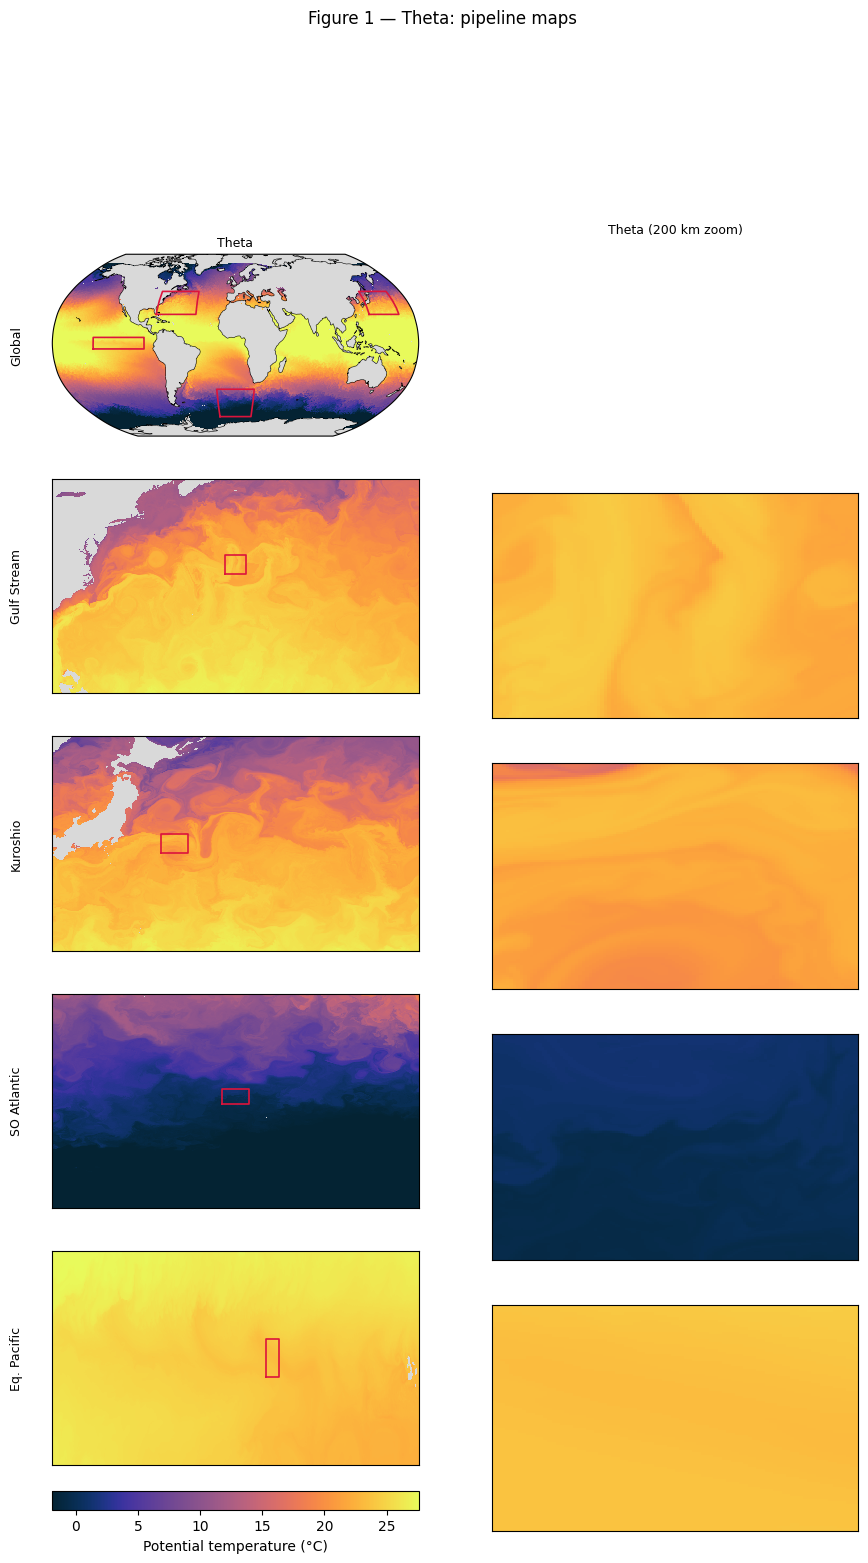

In [6]:
figure1_maps("Theta")

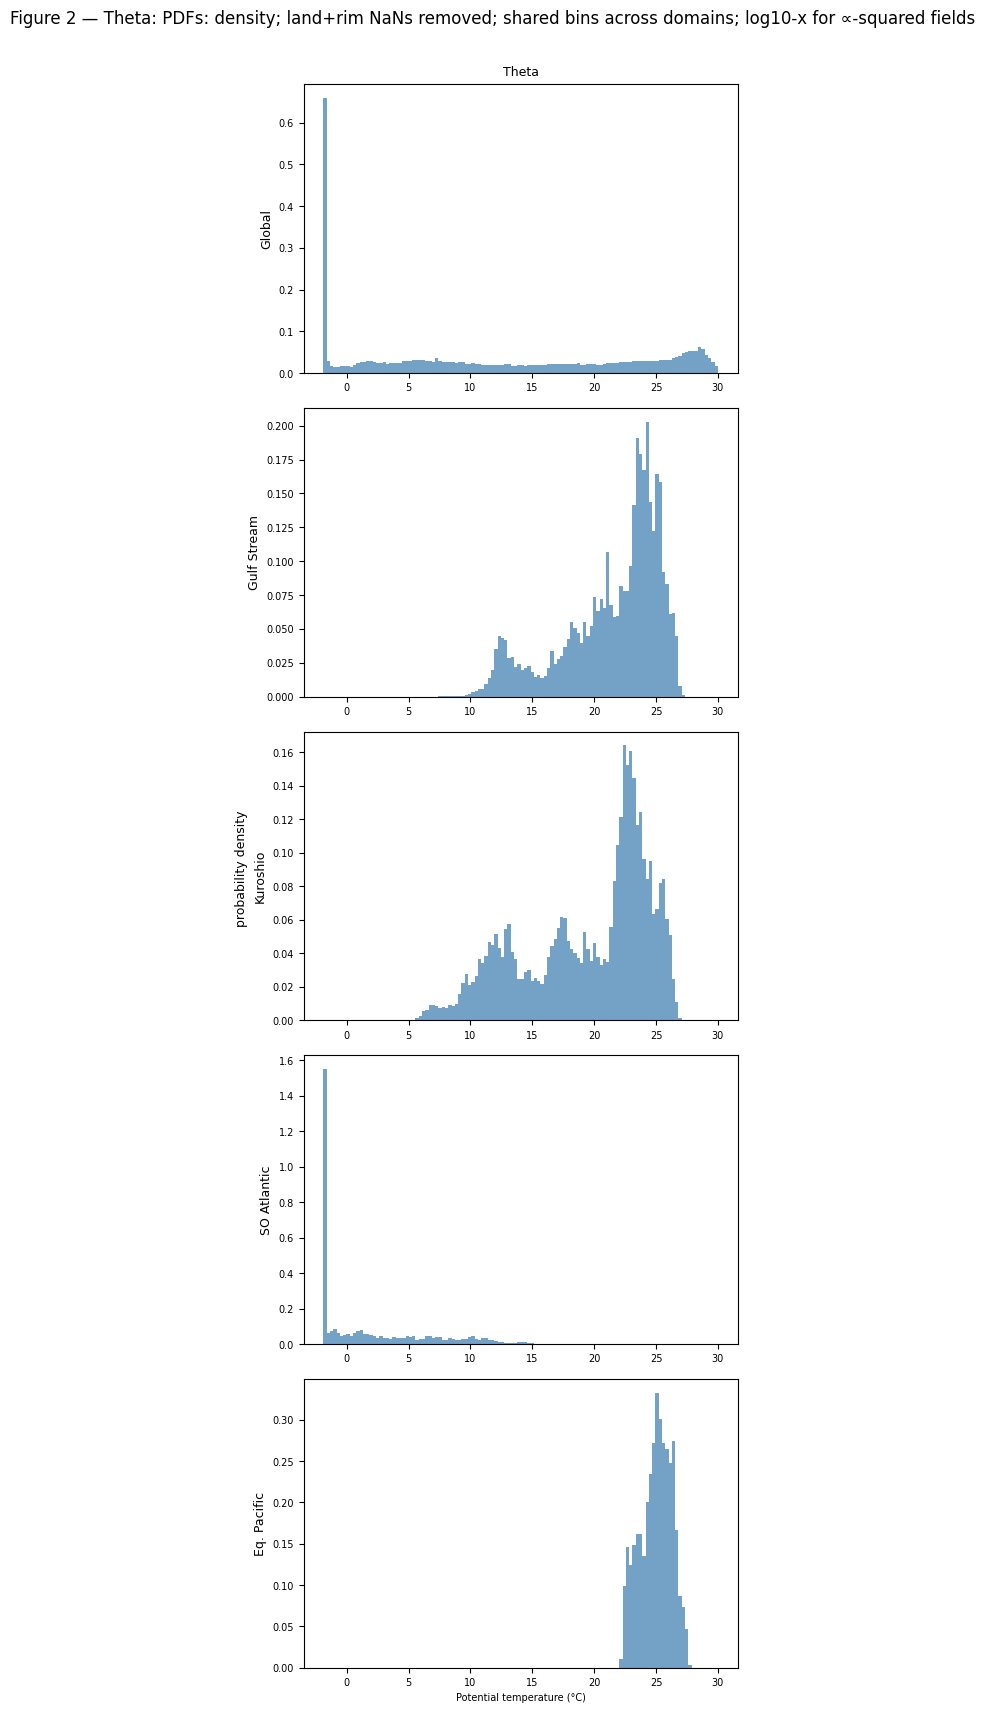

In [7]:
figure2_pdfs("Theta")

### 5.2 Salt (raw)

Model salinity.  Subtropical maxima, fresh ITCZ/plumes.

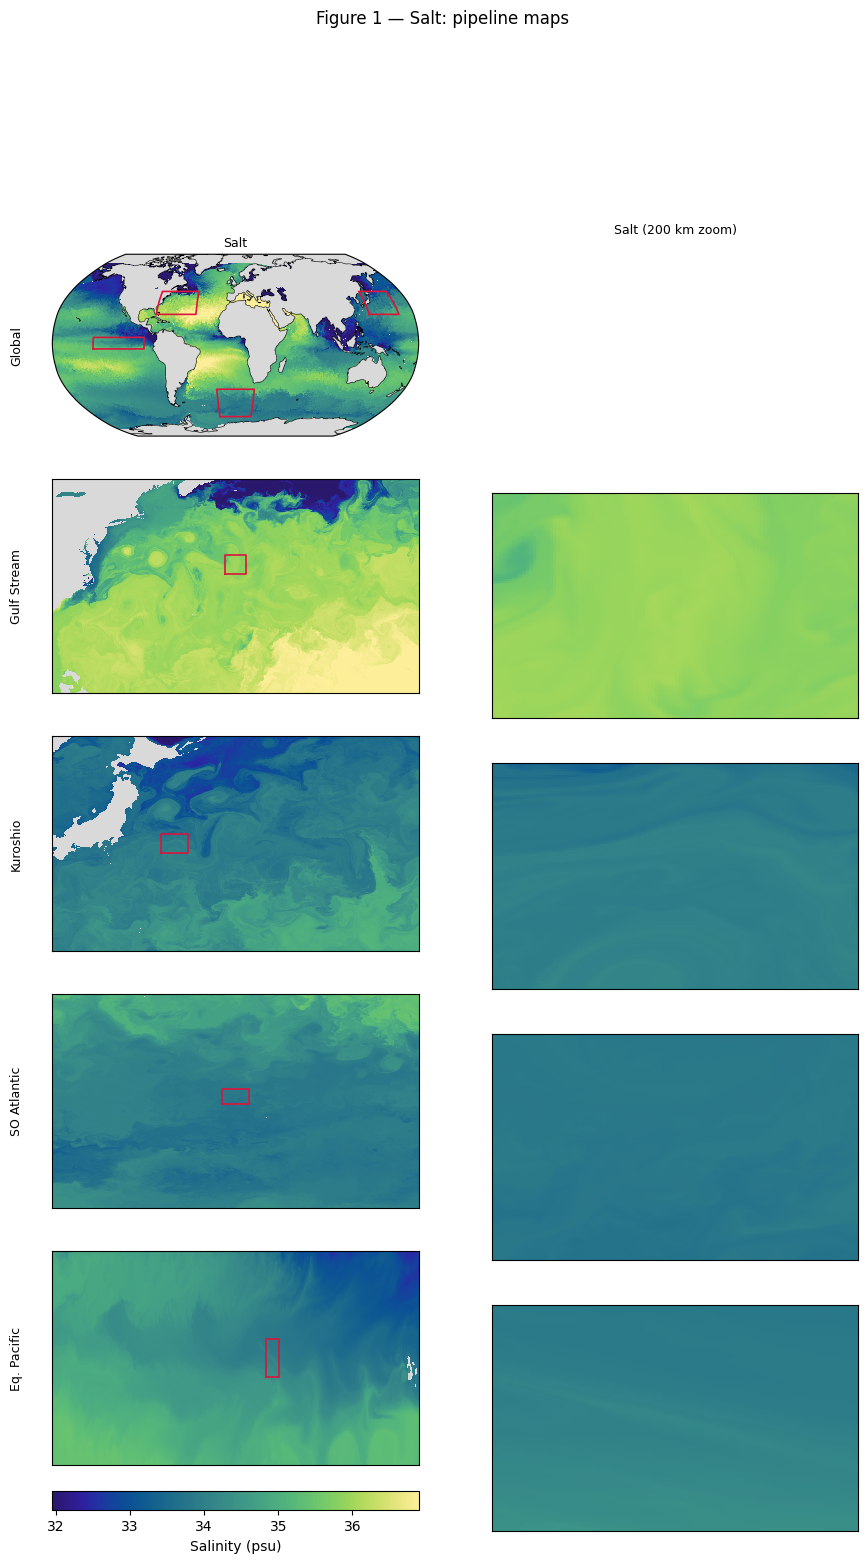

In [8]:
figure1_maps("Salt")

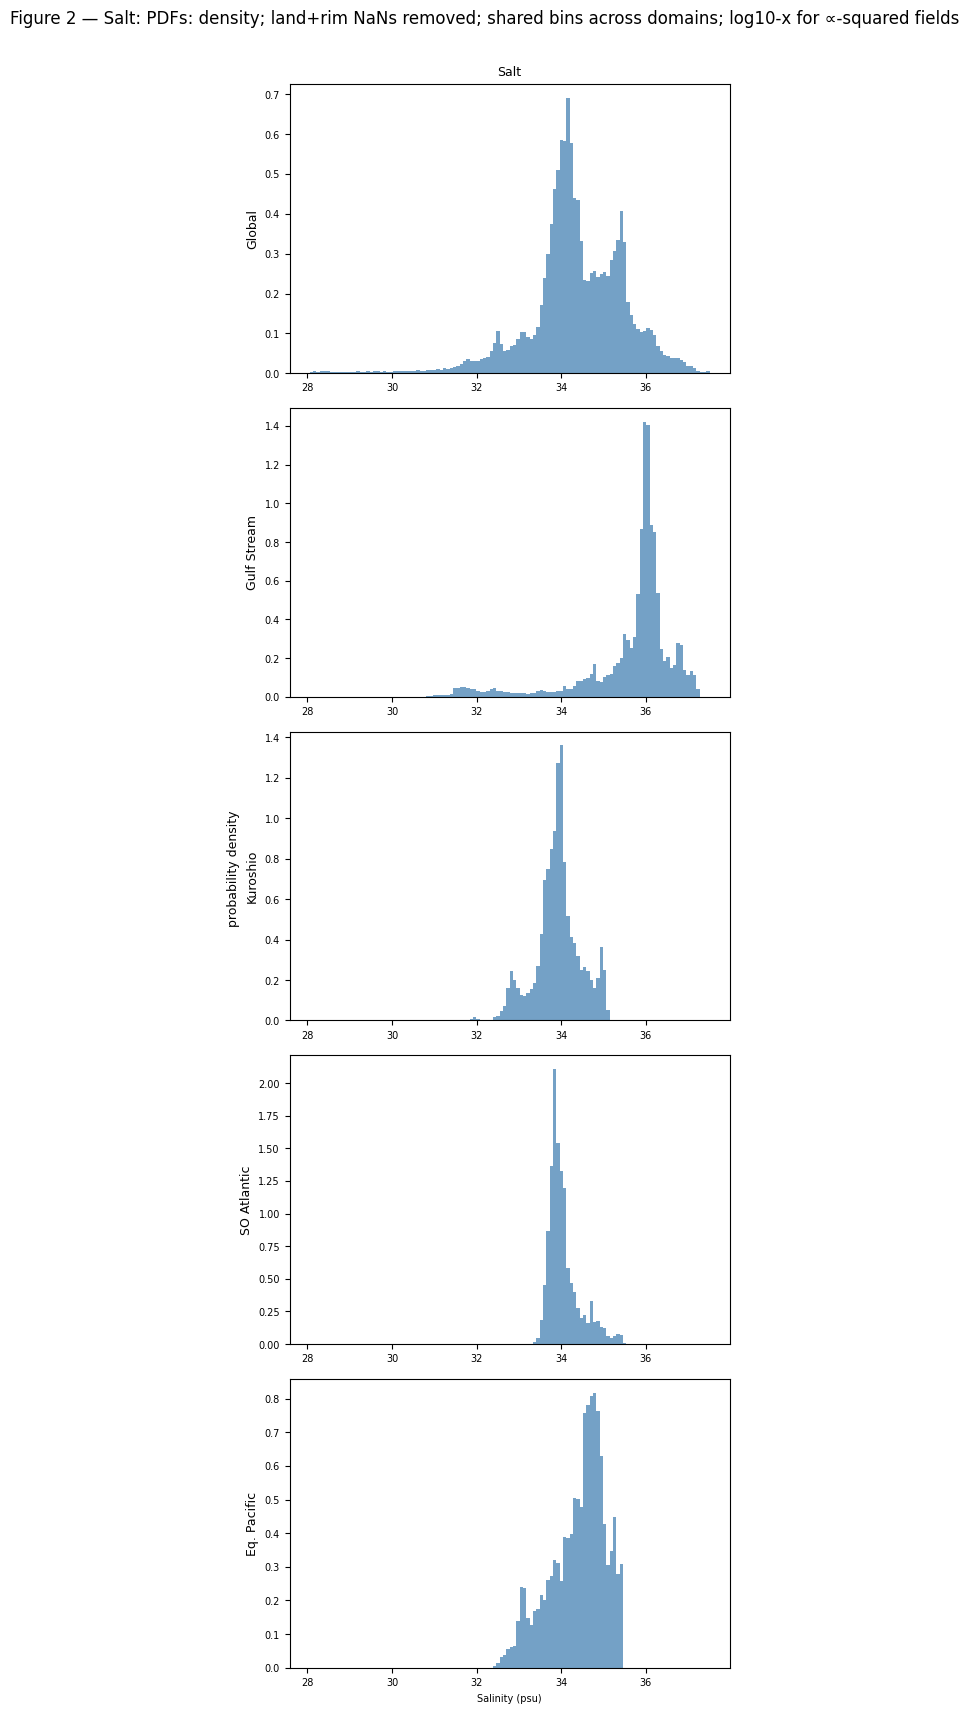

In [9]:
figure2_pdfs("Salt")

### 5.3 Eta (raw)

Sea-surface height anomaly.  Gyres, ACC gradient.

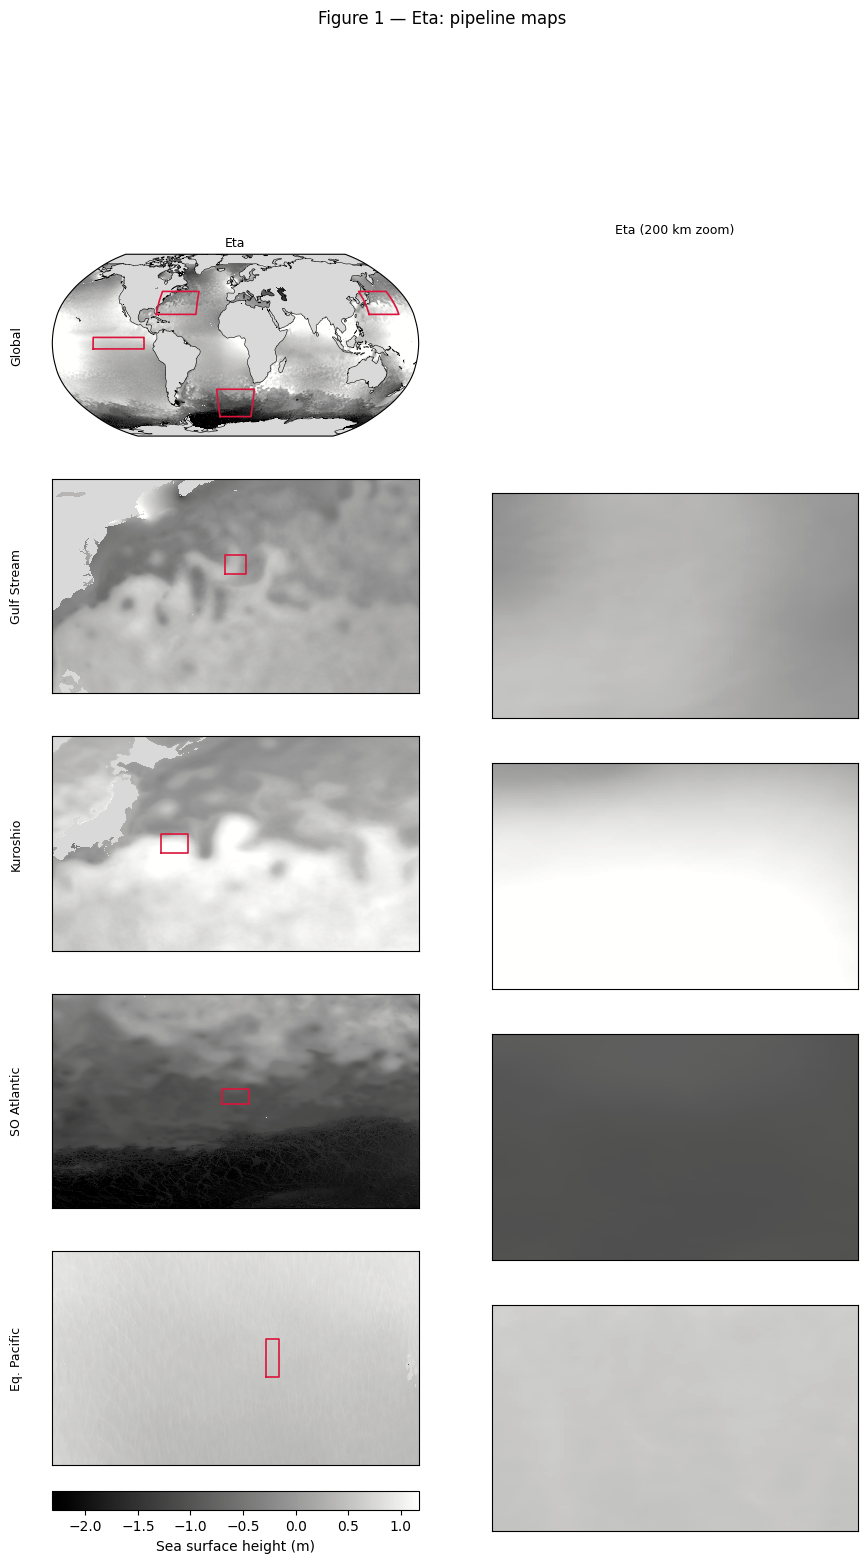

In [10]:
figure1_maps("Eta")

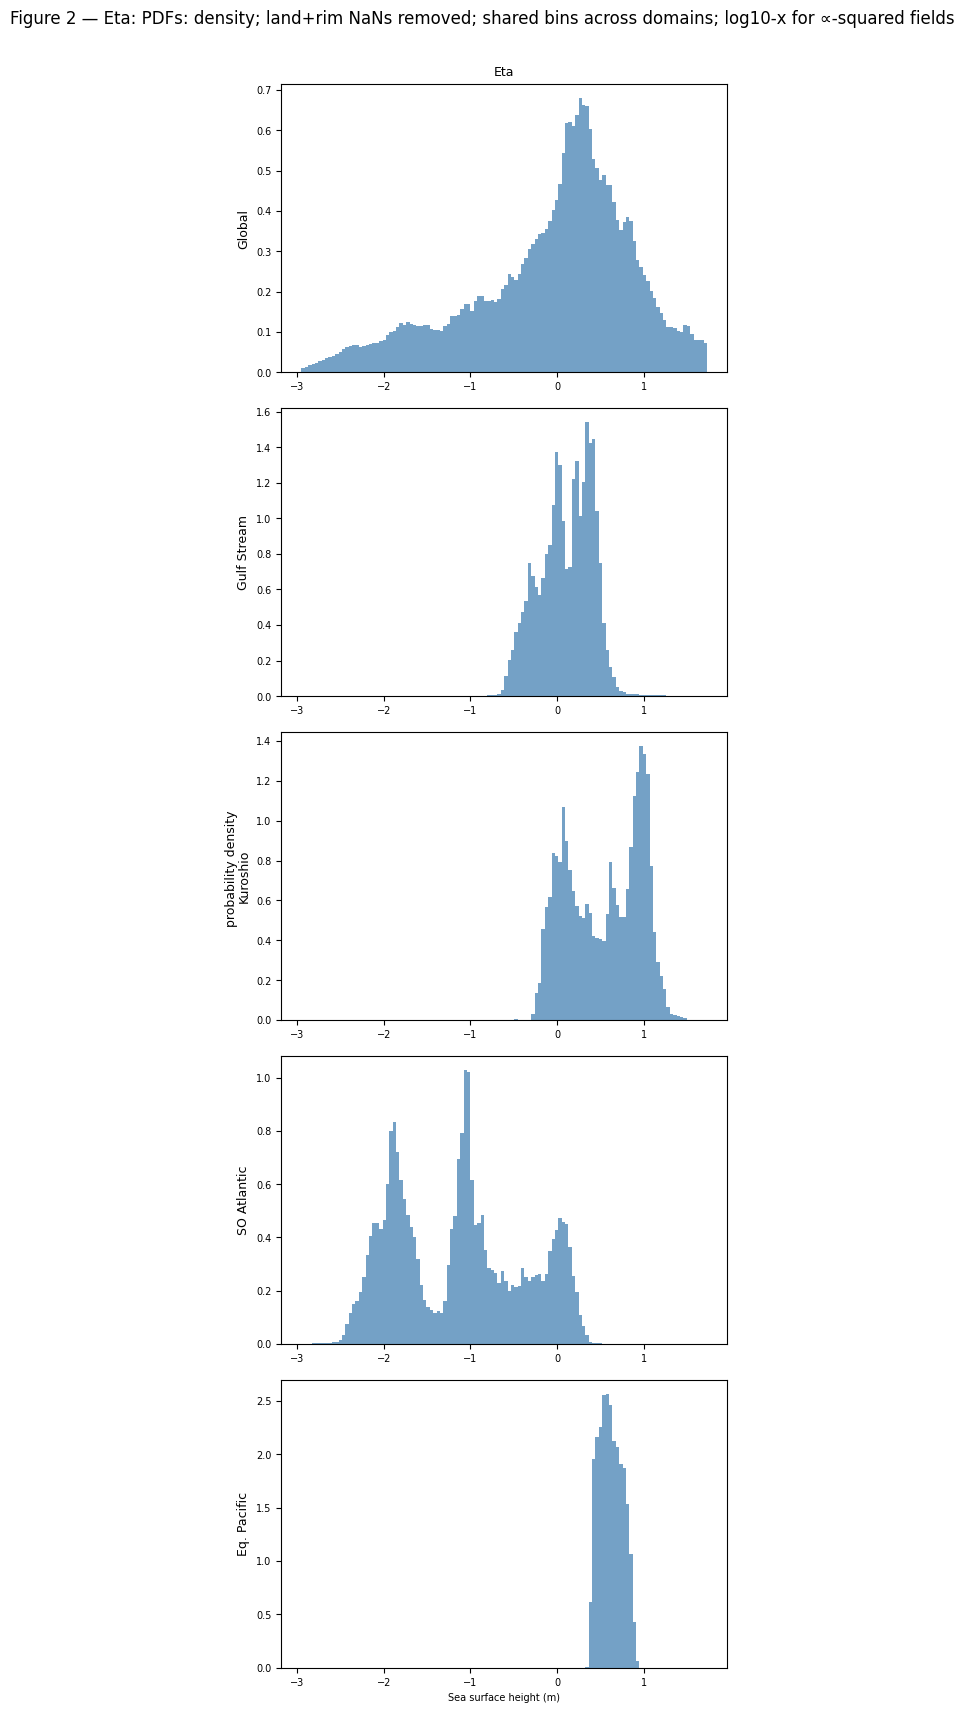

In [11]:
figure2_pdfs("Eta")

### 5.4 W (raw)

Vertical velocity at the top interface (k_l = 0) — ≈0 by construction; internal-wave signals dominate.

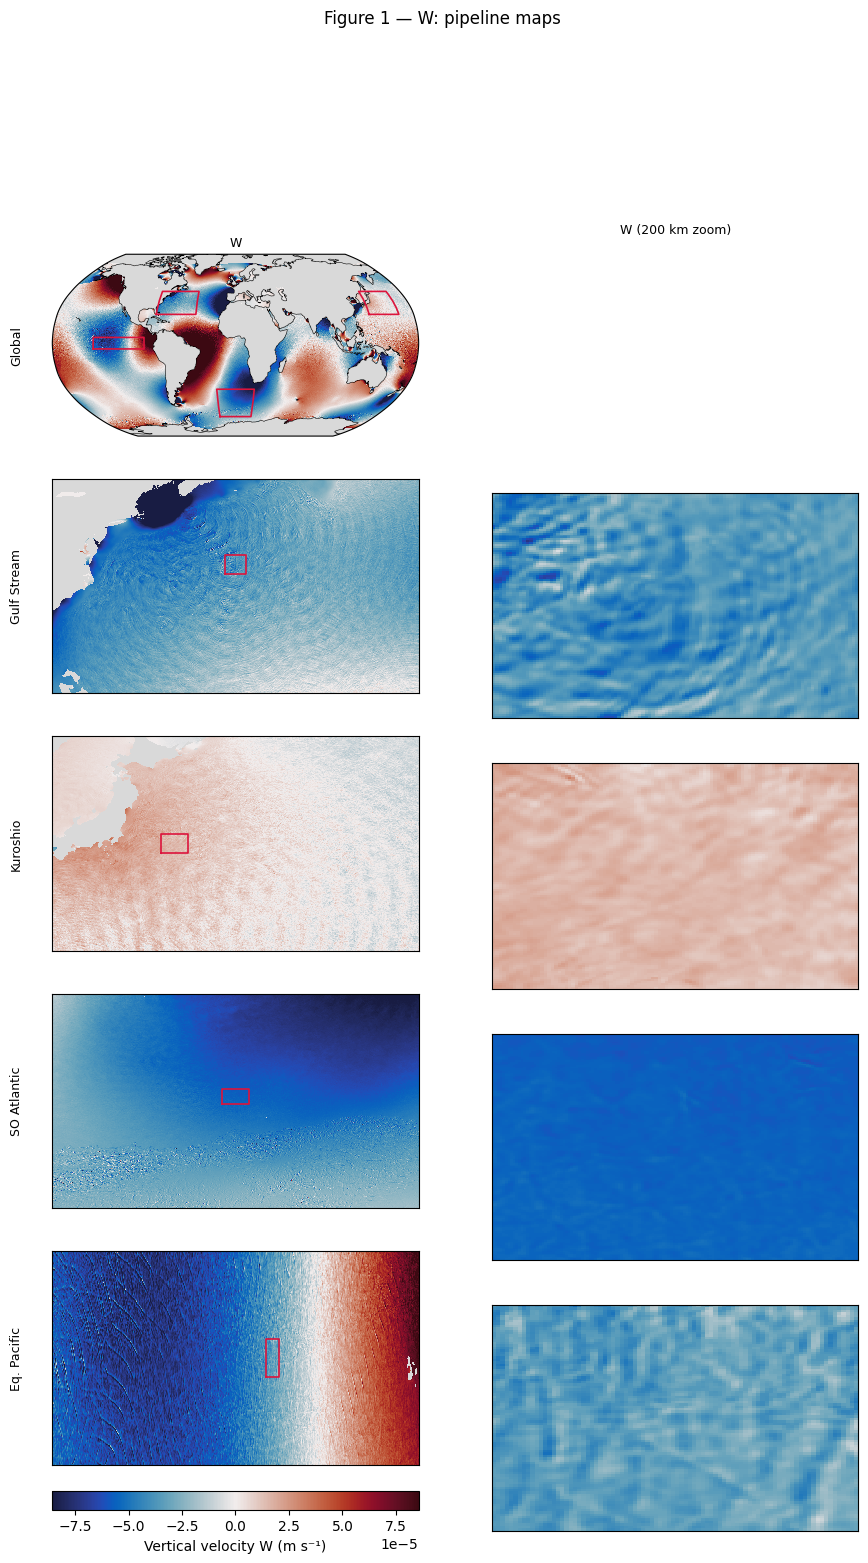

In [12]:
figure1_maps("W")

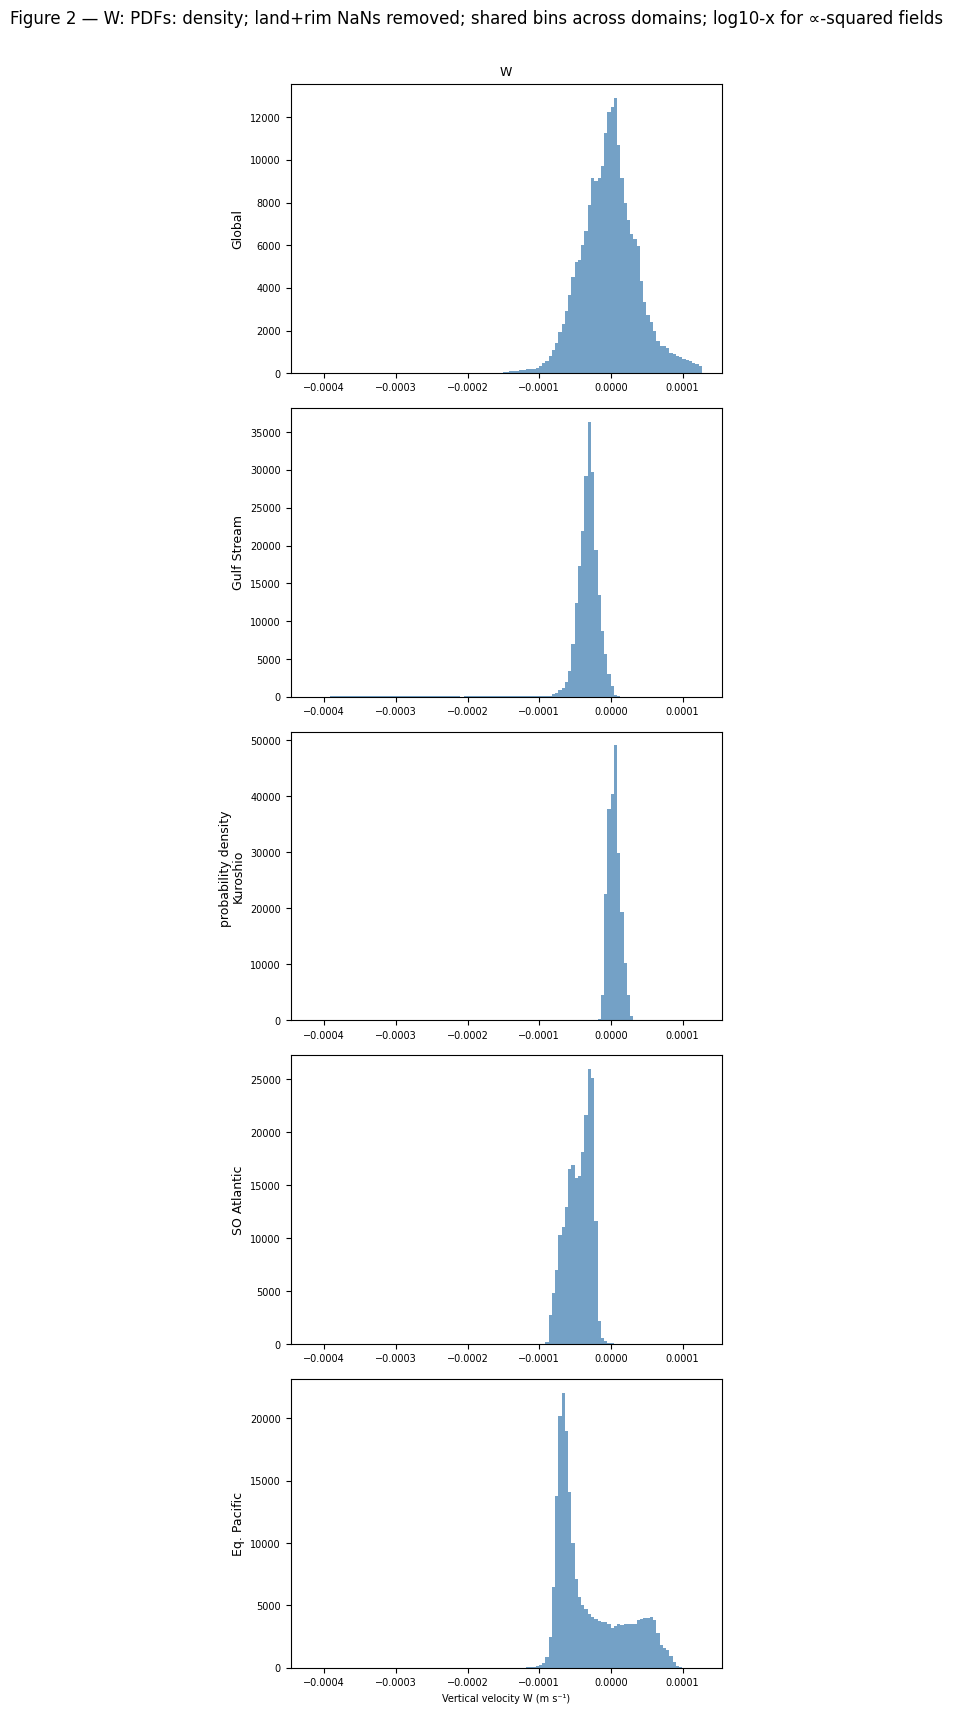

In [13]:
figure2_pdfs("W")

### 5.5 U (computed: eastward)

Staggered U,V interpolated to tracer points and rotated to geographic east via CS/SN.

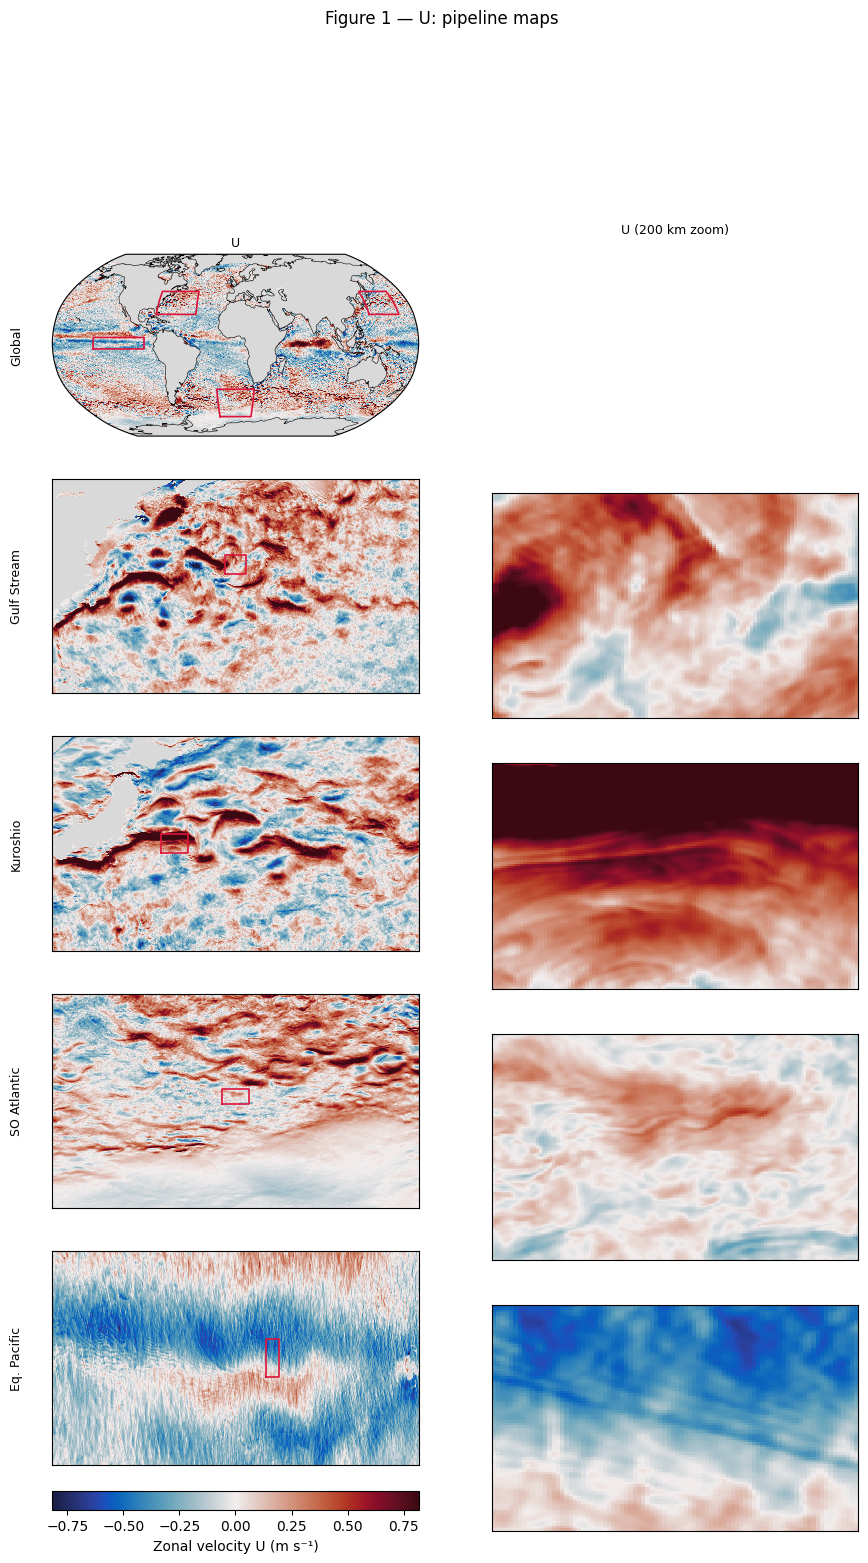

In [14]:
figure1_maps("U")

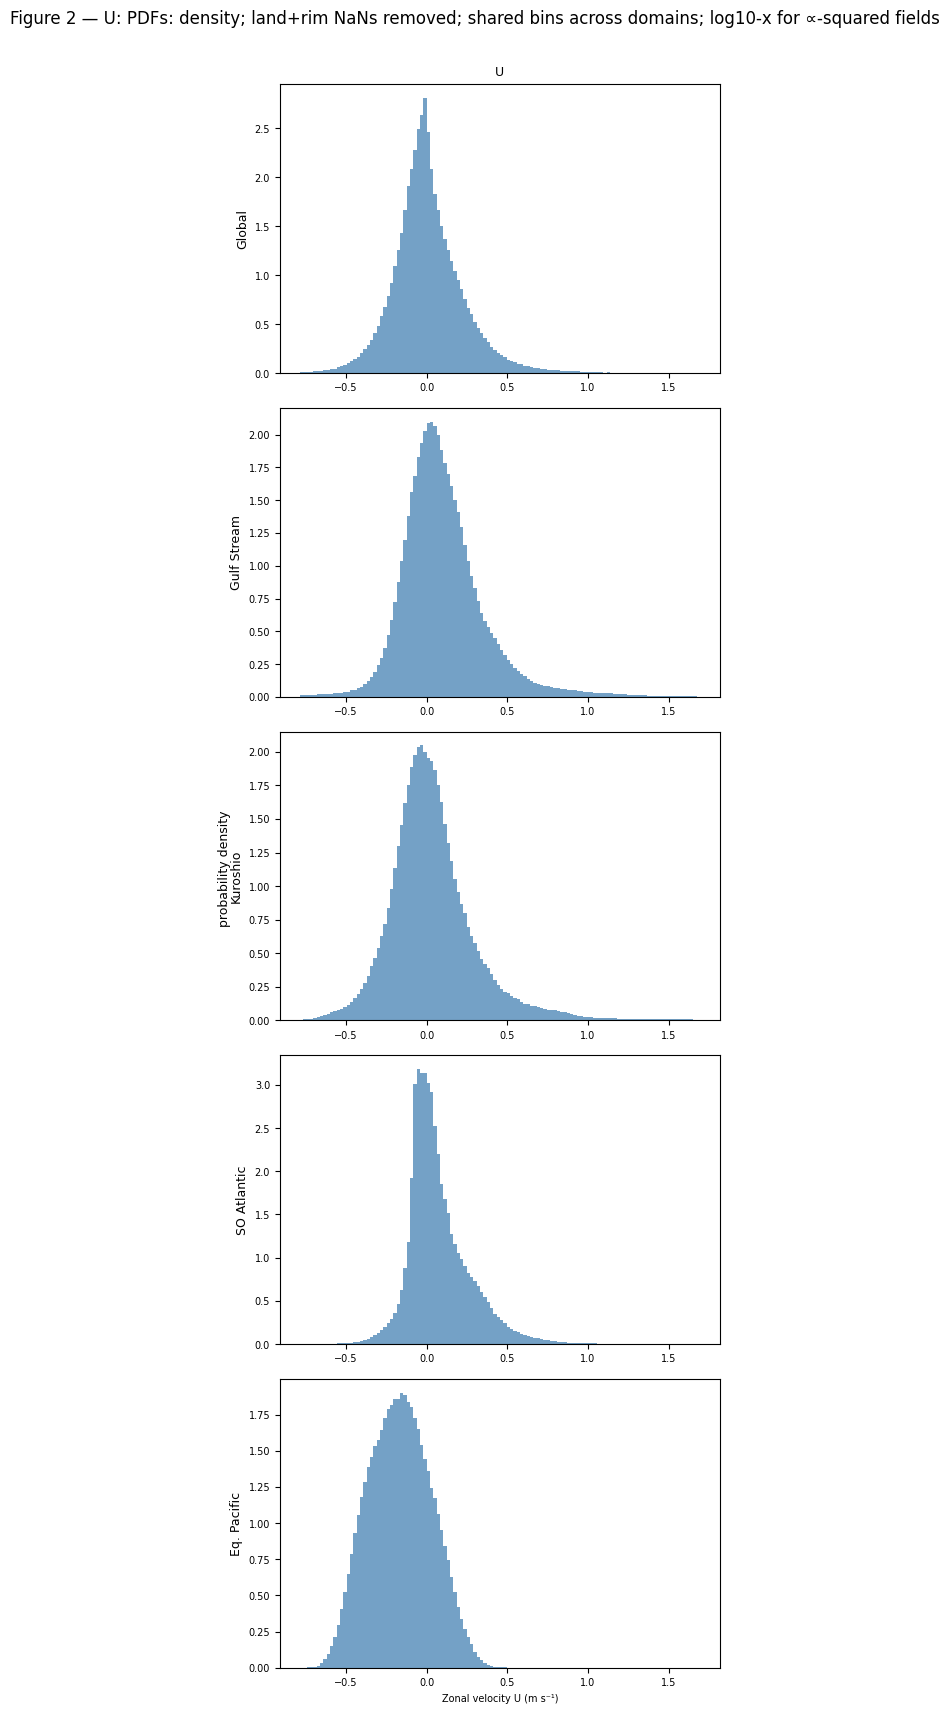

In [15]:
figure2_pdfs("U")

### 5.6 V (computed: northward)

Same rotation, northward component.

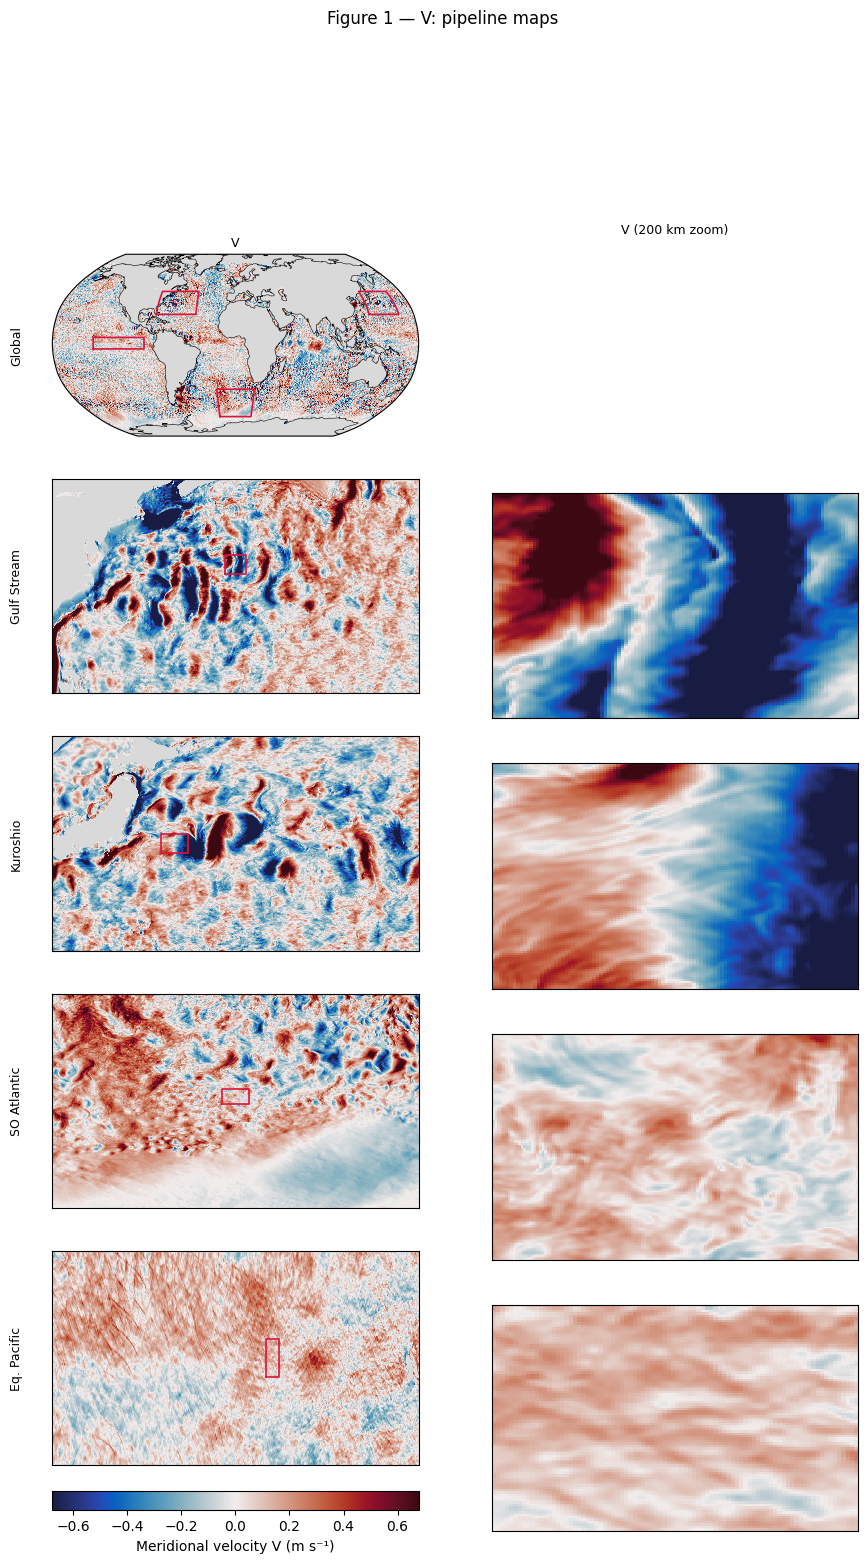

In [16]:
figure1_maps("V")

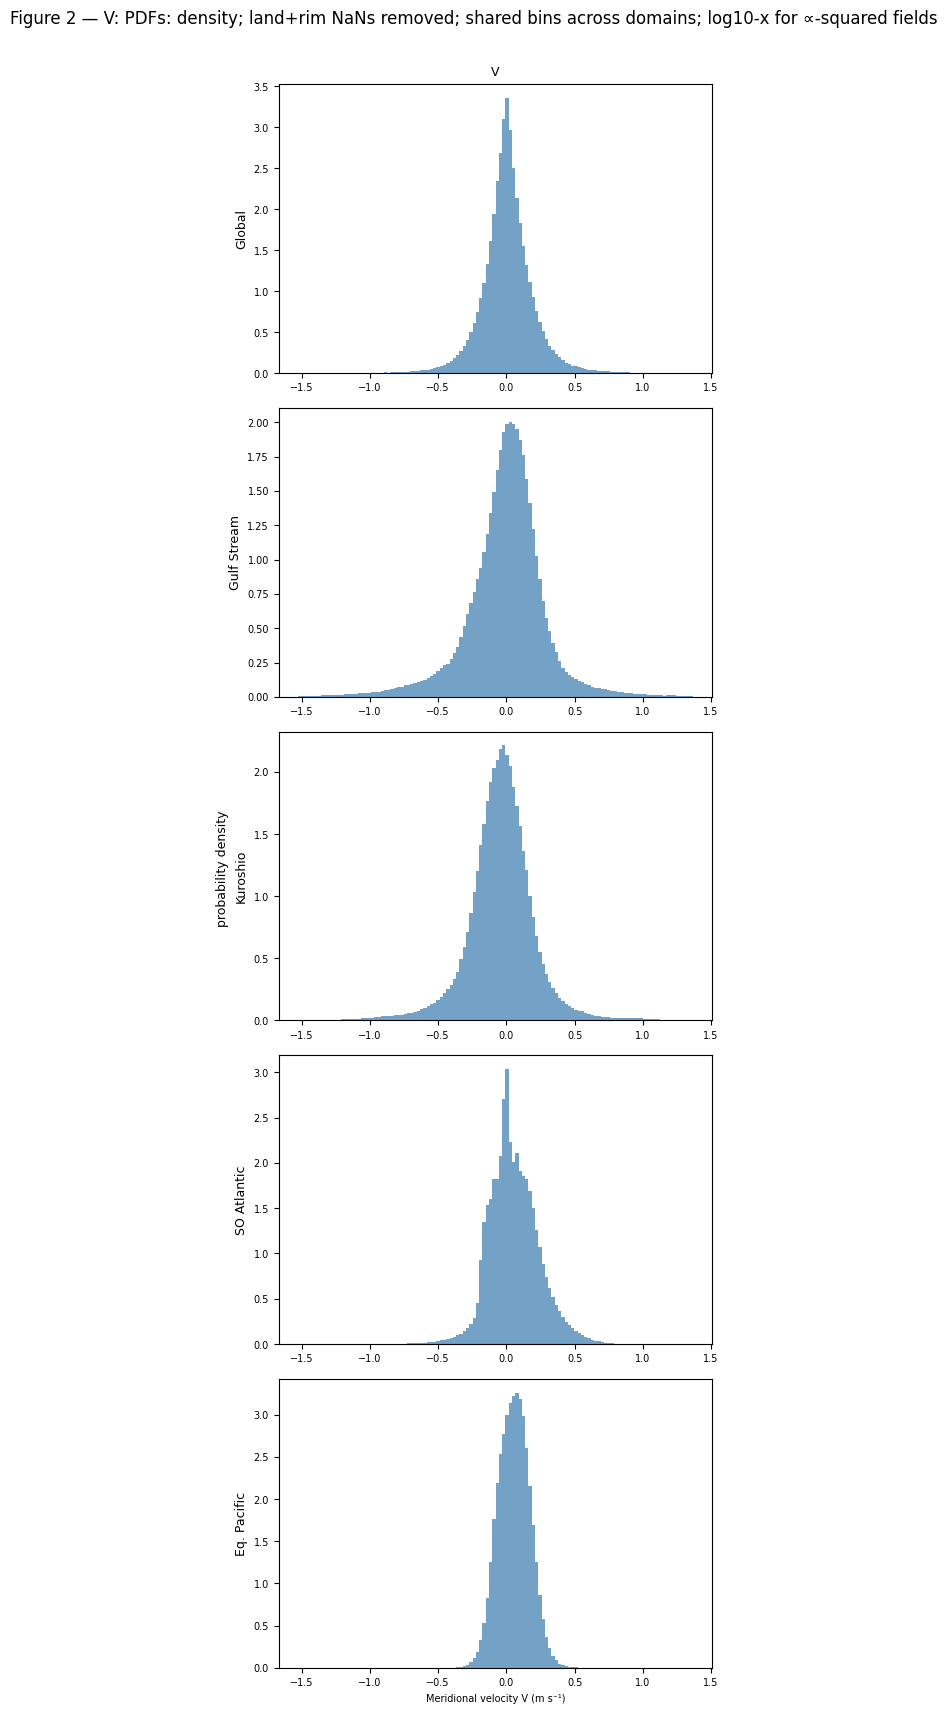

In [17]:
figure2_pdfs("V")

## Section 6 — Literature comparisons

One subsection per reference (a reference may validate several fields); only fields with published counterparts appear here.

### 6.1 Yu et al. (2021) — global Eta and U (LLC4320 itself)

Strongest possible reference: the SAME model.  Their snapshot is
2011-11-24; ours is 2012-11-09 — large-scale structure (gyres, ACC
SSH gradient, equatorial current system) should match closely;
mesoscale eddies will differ in phase.

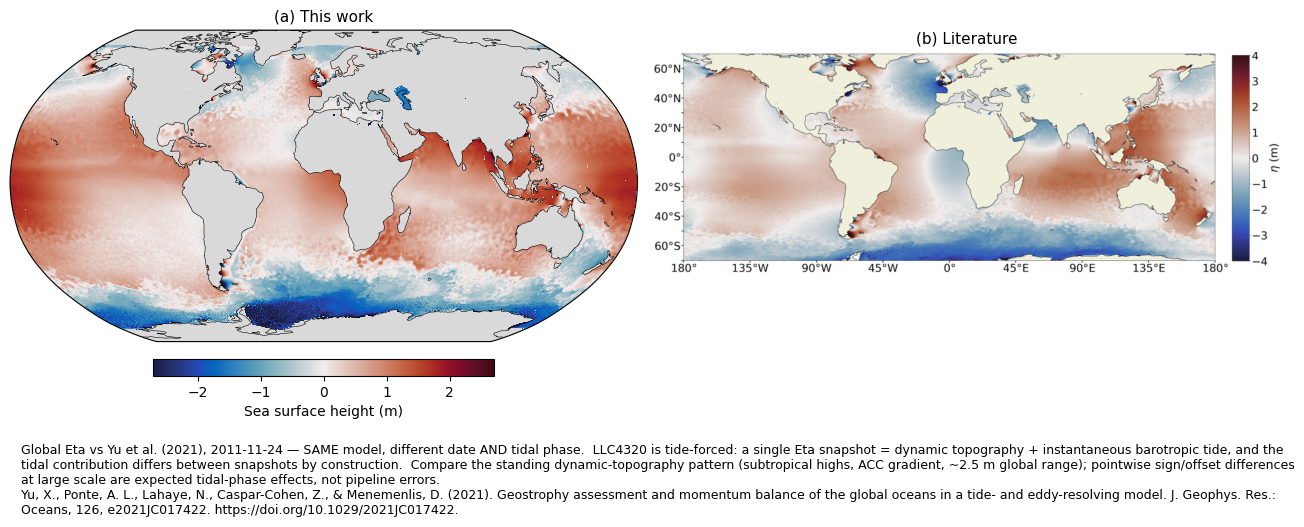

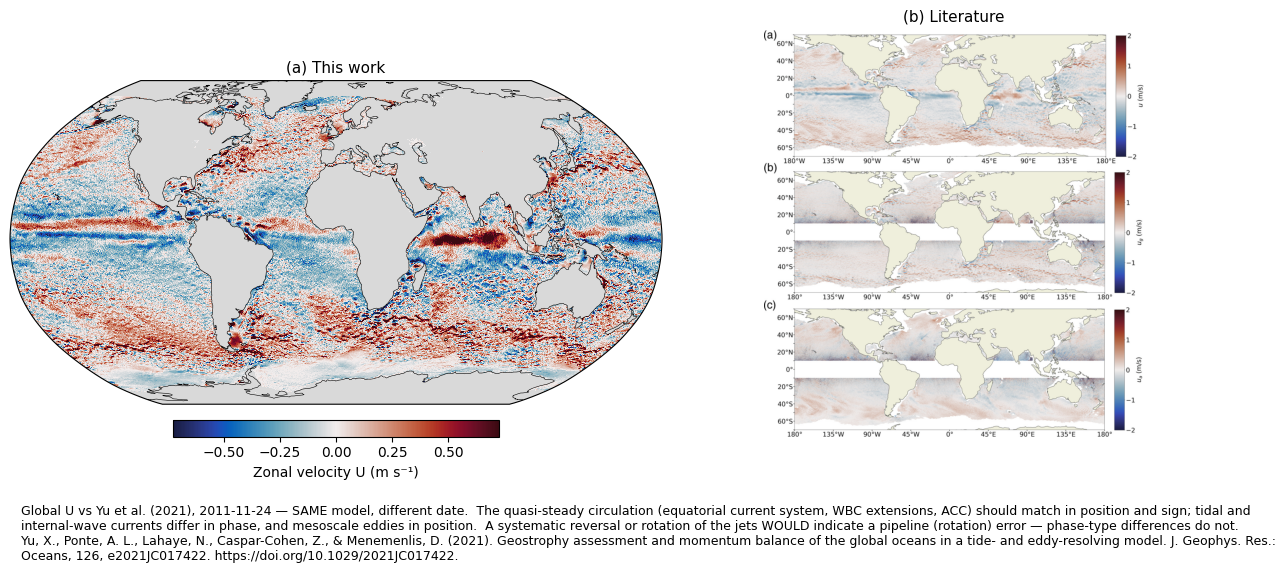

In [21]:
# Yu et al. (2021) comparison: global Eta and U maps (LLC4320,
# their 2011-11-24 vs our 2012-11-09 snapshot).  Both panels use
# the 'balance' diverging colormap.
import cartopy.crs as ccrs

from dbof.plotting.literature_comparison import side_by_side

YU_CMAP_CFG = {
    **CMAP_CFG,
    "Eta": ("balance", CMAP_CFG["Eta"][1]),
    "U": ("balance", CMAP_CFG["U"][1]),
}

CIT_YU = ("Yu, X., Ponte, A. L., Lahaye, N., Caspar-Cohen, Z., & "
          "Menemenlis, D. (2021). Geostrophy assessment and "
          "momentum balance of the global oceans in a tide- and "
          "eddy-resolving model. J. Geophys. Res.: Oceans, 126, "
          "e2021JC017422. https://doi.org/10.1029/2021JC017422.")

CAPTIONS = {
    "Eta": ("Global Eta vs Yu et al. (2021), 2011-11-24 — SAME "
            "model, different date AND tidal phase.  LLC4320 is "
            "tide-forced: a single Eta snapshot = dynamic "
            "topography + instantaneous barotropic tide, and the "
            "tidal contribution differs between snapshots by "
            "construction.  Compare the standing dynamic-"
            "topography pattern (subtropical highs, ACC gradient, "
            "~2.5 m global range); pointwise sign/offset "
            "differences at large scale are expected tidal-phase "
            "effects, not pipeline errors.\n" + CIT_YU),
    "U": ("Global U vs Yu et al. (2021), 2011-11-24 — SAME model, "
          "different date.  The quasi-steady circulation "
          "(equatorial current system, WBC extensions, ACC) should "
          "match in position and sign; tidal and internal-wave "
          "currents differ in phase, and mesoscale eddies in "
          "position.  A systematic reversal or rotation of the "
          "jets WOULD indicate a pipeline (rotation) error — "
          "phase-type differences do not.\n" + CIT_YU),
}


def _global_panel(field):
    """Renderer for one global Robinson panel.

    Inputs: field (str) — store channel name.
    Outputs: callable(ax).  Generated by LH and Claude
    """
    x, y, arr = region_arrays[field]["global"]
    arr = mask_wrap_cells(x, y, arr)   # seam/Arctic handling

    def _render(ax):
        ax.set_facecolor(LAND_COLOR)
        im, label = plot_global_field(
            ax, x, y, arr, field, YU_CMAP_CFG,
            diverging_cmaps=DIVERGING,
            transform=ccrs.PlateCarree(), add_coastline=True,
            coastline_kw={"linewidth": 0.4, "edgecolor": "k"})
        if im is not None:
            plt.colorbar(im, ax=ax, orientation="horizontal",
                         fraction=0.04, pad=0.04, label=label)
    return _render


for _field, _png in [
    ("Eta", "native-fields_eta_LLC4320_global_24NOV2011_"
            "Yu-et-al(2021).png"),
    ("U", "native-fields_u-ug_LLC4320_global_24NOV2011_"
          "Yu-et-al(2021).png"),
]:
    side_by_side(
        _global_panel(_field), LIT_DIR / _png,
        projection=ccrs.Robinson(),
        caption=CAPTIONS[_field],
    )
    plt.show()

## Summary — guard-style checks

Pass/fail checklist mirroring `dev/verify_subsets_real_data.py`:
finite fraction, plausible range, and channel-uniqueness guard on the
Gulf Stream domain.

In [20]:
# Summary: quick stats + uniqueness guard (Gulf Stream domain).
seen = {}
print(f"{'field':24s} {'finite%':>8s} {'min':>11s} "
      f"{'max':>11s} {'unique':>7s}")
for ch in CHANNELS:
    sub = region_arrays[ch]["gulf_stream"][2]
    finite = np.isfinite(sub)
    frac = 100.0 * finite.mean()
    key = hash(sub[finite][::997].tobytes()) if finite.any() else ch
    dup = seen.get(key)
    seen[key] = ch
    print(f"{ch:24s} {frac:7.1f}% {np.nanmin(sub):11.3g} "
          f"{np.nanmax(sub):11.3g} {'DUP!' if dup else 'ok':>7s}")
    assert dup is None, f"{ch} identical to {dup}"
print("\nAll checks passed.")

field                     finite%         min         max  unique
Theta                       89.8%        6.14        27.3      ok
Salt                        89.8%        26.1        38.8      ok
Eta                         89.8%       -1.55        2.68      ok
W                           89.8%   -0.000907    5.18e-05      ok
U                           89.6%       -4.14        4.13      ok
V                           89.6%       -4.82        2.18      ok

All checks passed.


**Cross-references** — the interp+rotation machinery used here is exercised on derived fields in `kinematic.ipynb` (Jacobian) and `frontogenesis.ipynb`; raw Theta/Salt/Eta feed `frontal_structure.ipynb` gradients.